Deep Learning with keras & Tensorflow

Download & Extract the dataset

In [11]:
# In VS Code Notebook, use Python cells just like in Colab. The commands below download the archive, extract it, and print the dataset files so you can verify the data is present.

import urllib.request
import tarfile
import os
import glob

url = 'https://github.com/sadeepj/eth-80/releases/download/0.0.1/eth-80.tar.gz'
dest = 'eth-80.tar.gz'

if not os.path.exists(dest):
    urllib.request.urlretrieve(url, dest)
    print('Downloaded:', dest)
else:
    print('Already downloaded:', dest)

if not os.path.isdir('eth-80'):
    with tarfile.open(dest, 'r:gz') as tar:
        tar.extractall()
    print('Extracted eth-80')
else:
    print('Already extracted: eth-80')

print('\nFiles in current directory:')
for name in sorted(os.listdir('.')):
    if name == dest or name == 'eth-80':
        print(name)

print('\nAll dataset files:')
all_files = sorted(glob.glob('eth-80/**/*', recursive=True))
for path in all_files:
    print(path)

print('\nTotal dataset entries under eth-80:', len(all_files))

Already downloaded: eth-80.tar.gz
Already extracted: eth-80

Files in current directory:
eth-80
eth-80.tar.gz

All dataset files:
eth-80\train_set
eth-80\train_set\apple
eth-80\train_set\apple\apple1
eth-80\train_set\apple\apple1\apple1-000-000.png
eth-80\train_set\apple\apple1\apple1-022-000.png
eth-80\train_set\apple\apple1\apple1-022-090.png
eth-80\train_set\apple\apple1\apple1-022-180.png
eth-80\train_set\apple\apple1\apple1-022-270.png
eth-80\train_set\apple\apple1\apple1-035-045.png
eth-80\train_set\apple\apple1\apple1-035-135.png
eth-80\train_set\apple\apple1\apple1-035-225.png
eth-80\train_set\apple\apple1\apple1-035-315.png
eth-80\train_set\apple\apple1\apple1-045-000.png
eth-80\train_set\apple\apple1\apple1-045-090.png
eth-80\train_set\apple\apple1\apple1-045-180.png
eth-80\train_set\apple\apple1\apple1-045-270.png
eth-80\train_set\apple\apple1\apple1-066-027.png
eth-80\train_set\apple\apple1\apple1-066-063.png
eth-80\train_set\apple\apple1\apple1-066-117.png
eth-80\train_set

Verify that the data is there Correctly Exracted 

In [ ]:
from PIL import Image
from IPython.display import display

In [13]:
im = Image.open('eth-80/train_set/dog/dog4/dog4-066-207.png')

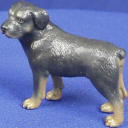

In [18]:
display(im)

In [20]:
import numpy as np
image_array = np.array(im)
image_array.shape
image_array

array([[[ 68,  92, 170],
        [ 76,  92, 176],
        [ 74,  89, 178],
        ...,
        [ 82, 100, 183],
        [ 81, 102, 180],
        [ 82,  99, 183]],

       [[ 72,  89, 176],
        [ 75,  91, 174],
        [ 74,  91, 174],
        ...,
        [ 80, 100, 181],
        [ 81,  99, 181],
        [ 84, 100, 182]],

       [[ 77,  88, 177],
        [ 77,  91, 176],
        [ 74,  90, 174],
        ...,
        [ 79,  99, 180],
        [ 84,  98, 185],
        [ 81,  98, 179]],

       ...,

       [[109, 139, 217],
        [124, 151, 223],
        [116, 139, 218],
        ...,
        [ 89, 113, 196],
        [106, 131, 209],
        [102, 128, 207]],

       [[110, 138, 218],
        [120, 144, 224],
        [115, 137, 218],
        ...,
        [ 97, 127, 205],
        [110, 136, 214],
        [111, 136, 217]],

       [[114, 140, 217],
        [115, 139, 218],
        [117, 139, 219],
        ...,
        [106, 135, 214],
        [109, 132, 215],
        [109, 135, 220]]

Module import & Variable initialization

In [1]:
import numpy as np
import tensorflow as tf 
from tensorflow import keras
from tensorflow.keras import layers
from tensorboardcolab import TensorBoard, TensorBoardColabCallback
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
# Deimension of our images
img_width, img_height = 128 , 128

In [3]:
train_data_dir = 'eth-80/train_set'
validation_data_dir = 'eth-80/val_set'

np_train_samples = 2952
np_validation_samples = 328

epochs = 50
batch_size = 32

Define the CNN Model 

In [ ]:
#New tensorflow Model

input_shape = (img_width, img_height, 3)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Conv2D(32, (3, 3),activation='relu',input_shape=input_shape))
model.add(tf.keras.layers.MaxPool2D(pool_size=(2, 2)))
model.add(tf.keras.layers.Conv2D(32, (3, 3),activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=(2, 2)))
model.add(tf.keras.layers.MaxPool2D(pool_size=(2, 2)))

model.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=(2, 2)))

model.add(tf.keras.layers.Flatten())

